In [661]:
cd C:\Users\kavin\Downloads\PMGSY_Roads

C:\Users\kavin\Downloads\PMGSY_Roads


In [662]:
! pip install geopandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<>:7: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:7: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\kavin\AppData\Local\Temp\ipykernel_10136\3012825477.py:7: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  roads = gpd.read_file("DRRP6\Road_DRRP6.shp")


✅ Shapefile loaded successfully!
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 26065 entries, 0 to 26064
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   ER_ID       26065 non-null  int64   
 1   STATE_ID    26065 non-null  int64   
 2   BLOCK_ID    26065 non-null  int64   
 3   DISTRICT_I  26065 non-null  int64   
 4   DRRP_ROAD_  26065 non-null  str     
 5   RoadCatego  26065 non-null  str     
 6   RoadName    26065 non-null  str     
 7   RoadOwner   26065 non-null  str     
 8   geometry    26065 non-null  geometry
dtypes: geometry(1), int64(4), str(4)
memory usage: 1.8 MB
None


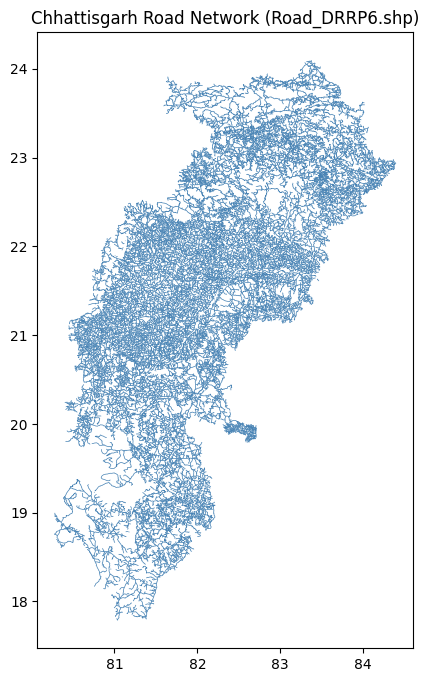

In [663]:
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt

# Load the shapefile
roads = gpd.read_file("DRRP6\Road_DRRP6.shp")

# Display basic info
print("✅ Shapefile loaded successfully!")
print(roads.info())

# Plot the shapefile
roads.plot(figsize=(10, 8), color='steelblue', linewidth=0.5)
plt.title("Chhattisgarh Road Network (Road_DRRP6.shp)")
plt.show()


### District Gujarat

In [664]:
# Path to the Indian district shapefile
district_path = r"shrug_data\shrug_data\shrug-pc11dist-poly-shp\district.shp"

# Check path
print("Using shapefile path:", district_path)

# Load the shapefile
district = gpd.read_file(district_path)


Using shapefile path: shrug_data\shrug_data\shrug-pc11dist-poly-shp\district.shp


In [665]:
# Filter to state 24 (Gujarat)
gujarat_d = district[district['pc11_s_id'] == '24'] 

### PMGSY 2015 village info 

In [666]:
# Path to the csv
pmgsy_2015 = r"shrug_data\shrug_data\shrug-pmgsy-csv\pmgsy_2015_shrid.csv"

# Check path
print("Using shapefile path:", pmgsy_2015)

# Load the csv
pmgsy_2015 = gpd.read_file(pmgsy_2015)

# Display basic info
print(pmgsy_2015.info())

Using shapefile path: shrug_data\shrug_data\shrug-pmgsy-csv\pmgsy_2015_shrid.csv
<class 'pandas.DataFrame'>
RangeIndex: 589090 entries, 0 to 589089
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   shrid2                   589090 non-null  str  
 1   road_award_date_new      589090 non-null  str  
 2   road_award_date_upg      589090 non-null  str  
 3   road_comp_date_new       589090 non-null  str  
 4   road_comp_date_upg       589090 non-null  str  
 5   road_comp_date_stip_new  589090 non-null  str  
 6   road_comp_date_stip_upg  589090 non-null  str  
 7   road_sanc_year_new       589090 non-null  str  
 8   road_sanc_year_upg       589090 non-null  str  
 9   road_length_new          589090 non-null  str  
 10  road_length_upg          589090 non-null  str  
 11  road_cost_new            589090 non-null  str  
 12  road_cost_upg            589090 non-null  str  
 13  road_cost_sanc_new 

In [667]:
#only choose gujarat shrid IDs 
pmgsy_2015["state"] = pmgsy_2015["shrid2"].str.split("-").str[1]
gvills_pmgsy_info =pmgsy_2015[pmgsy_2015["state"]== '24']
#vills_pmgsy_info.head() #7613


### Clean Gujarat villages to only those with pmgsy roads served

In [668]:
gvills_pmgsy_info = gvills_pmgsy_info.replace(r'^\s*$', None, regex=True).drop(columns=["state"])
gvills_pmgsy_info.isna().sum()

shrid2                         0
road_award_date_new        16067
road_award_date_upg        17731
road_comp_date_new         16200
road_comp_date_upg         17729
road_comp_date_stip_new    16220
road_comp_date_stip_upg    17731
road_sanc_year_new         16046
road_sanc_year_upg         17729
road_length_new            16200
road_length_upg            17729
road_cost_new              16200
road_cost_upg              17729
road_cost_sanc_new         16200
road_cost_sanc_upg         17729
road_cost_state_new        16200
road_cost_state_upg        17729
road_name_new              16206
road_name_upg              17733
dtype: int64

In [669]:
# Get all columns except 'shrid2'
other_cols = [c for c in gvills_pmgsy_info.columns if c != "shrid2"]

# Drop rows where all other columns are NaN
vills_pmgsy_info_clean = gvills_pmgsy_info.dropna(subset=other_cols, how="all")

print("Before:", gvills_pmgsy_info.shape)
print("After:", vills_pmgsy_info_clean.shape) #2113/17969= 

vills_pmgsy_info_clean.head()

Before: (17949, 19)
After: (2113, 19)


,shrid2,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,road_length_upg,road_cost_new,road_cost_upg,road_cost_sanc_new,road_cost_sanc_upg,road_cost_state_new,road_cost_state_upg,road_name_new,road_name_upg
458944,11-24-468-03722-506438,2002-09-30,NaN,2005-06-01,NaN,2002-12-15,NaN,2001.0,NaN,1.0,NaN,10.35,NaN,13.8,NaN,0.0,NaN,V.R. to Umarsar app.road,NaN
458978,11-24-468-03722-506476,2005-08-01,NaN,2006-03-01,NaN,2006-05-30,NaN,2004.0,NaN,1.1,NaN,12.07,NaN,10.4,NaN,0.0,NaN,O.D.R. to Audivandh Road,NaN
459011,11-24-468-03722-506516,2002-09-30,NaN,2005-08-01,NaN,2002-12-15,NaN,2001.0,NaN,0.5,NaN,10.88,NaN,7.55,NaN,0.0,NaN,V.R. to Zulrai app.road,NaN
459023,11-24-468-03723-506529,2007-07-06,NaN,2008-08-01,NaN,2008-04-06,NaN,2006.0,NaN,0.8,NaN,14.6,NaN,14.76,NaN,0.0,NaN,Gedi - Gedi pabunagar road,NaN
459043,11-24-468-03723-506549,2005-08-23,NaN,2006-03-01,NaN,2006-05-22,NaN,2004.0,NaN,1.2,NaN,40.91,NaN,16.44,NaN,0.0,NaN,V.R. to Ravnani Road,NaN


In [670]:
#number of villages that received roads after 2013 (ie could be pmgsy 2)
vills_pmgsy_info_clean[vills_pmgsy_info_clean['road_award_date_new']>'2013-04-01'][['road_award_date_new']].value_counts().sum()

np.int64(71)

### Merge with shrid2_open.shp

In [671]:
#shrid2 are the village codes, what does pc11_id even mean?
shrid2_path = r"shrug_data\shrug_data\shrug-shrid-poly-shp\shrid2_open.shp"

# Load the keys
shrid2_open =gpd.read_file(shrid2_path)
# Display basic info
print("✅ Shapefile loaded successfully!")
print(shrid2_open.info())

✅ Shapefile loaded successfully!
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 595438 entries, 0 to 595437
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   shrid2      595438 non-null  str     
 1   pc11_id     594139 non-null  str     
 2   n           594139 non-null  float64 
 3   geometry_t  594139 non-null  str     
 4   polysource  595438 non-null  str     
 5   n_ncontig   1299 non-null    float64 
 6   maxdist_km  1299 non-null    float64 
 7   geometry    595438 non-null  geometry
dtypes: float64(3), geometry(1), str(4)
memory usage: 36.3 MB
None


In [672]:
#only choose gujarat shrid IDs 
shrid2_open["state"] = shrid2_open["shrid2"].str.split("-").str[1]
shrid2open_g =shrid2_open[shrid2_open["state"]== '24']
shrid2open_g.head()

,shrid2,pc11_id,n,geometry_t,polysource,n_ncontig,maxdist_km,geometry,state
458370,11-24-468-03722-506426,506426,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((68.67508 23.79894, 68.67491 23.7975,...",24
458371,11-24-468-03722-506427,506427,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((68.70089 23.82176, 68.70275 23.81861...",24
458372,11-24-468-03722-506428,506428,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((68.72108 23.82161, 68.72118 23.82107...",24
458373,11-24-468-03722-506429,506429,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((68.74261 23.82737, 68.74516 23.827, ...",24
458374,11-24-468-03722-506430,506430,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((68.77345 23.82915, 68.77743 23.82895...",24


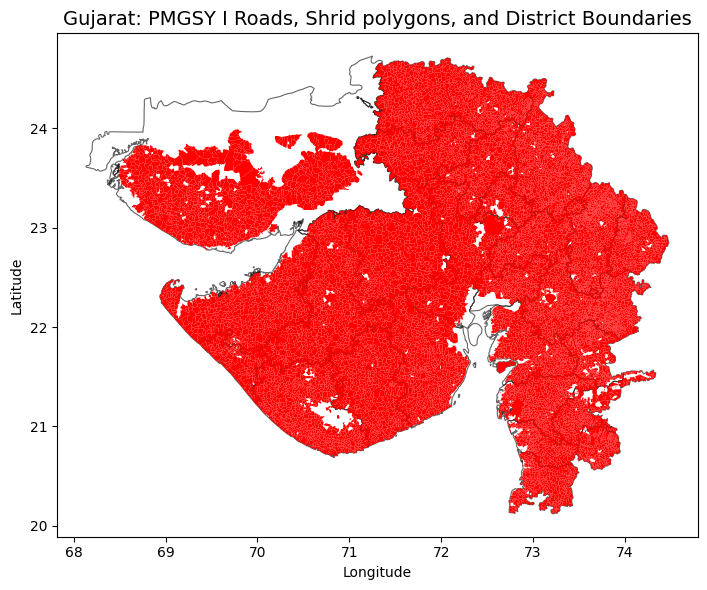

In [673]:
fig, ax = plt.subplots(figsize=(8,6))

# Plot districts (green background)
gujarat_d.plot(ax=ax, color='none', edgecolor='black', linewidth=0.8, alpha=0.6)

#plot shrid villages
shrid2open_g.plot(ax=ax, color='red', linewidth=0.2)

# Add title and clean layout
ax.set_title("Gujarat: PMGSY I Roads, Shrid polygons, and District Boundaries", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [674]:
vills_pmgsy=shrid2open_g.merge(vills_pmgsy_info_clean, on="shrid2", how="inner").drop(columns=["geometry_t"])
vills_pmgsy['geometry'].isna().sum() #0

np.int64(0)

In [675]:
vills_pmgsy['road_sanc_year_upg'].value_counts()

road_sanc_year_upg
2000.0    53
2007.0    48
2001.0    48
2008.0    33
2006.0    17
2005.0    14
2003.0     7
Name: count, dtype: int64

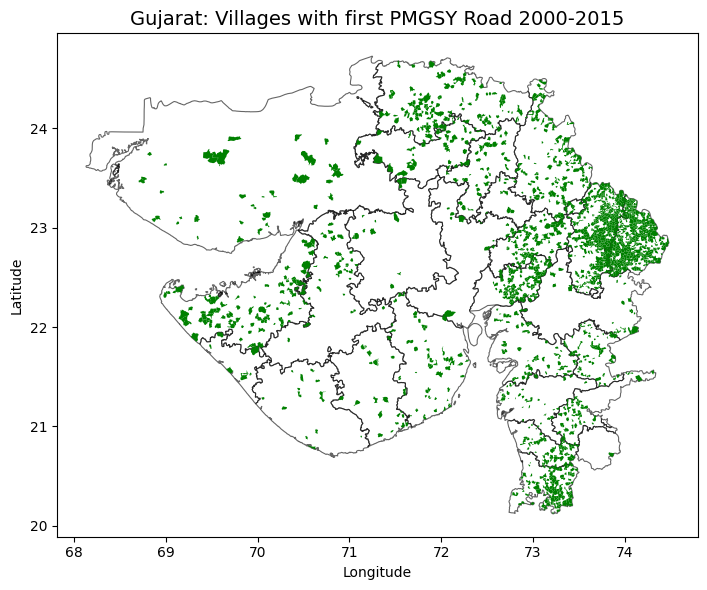

In [676]:
fig, ax2 = plt.subplots(figsize=(8,6))

# Plot districts (green background)
gujarat_d.plot(ax=ax2, color='none', edgecolor='black', linewidth=0.8, alpha=0.6)

#plot shrid villages
vills_pmgsy.plot(ax=ax2, color='green', linewidth=0.2)

# Add title and clean layout
ax2.set_title("Gujarat: Villages with first PMGSY Road 2000-2015", fontsize=14)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### PMGSY-I

Using shapefile path: PMGSY-6states-20260222T075336Z-1-001\PMGSY-6states\PMGSY-I\Proposal_PMGSY-I_Gujarat


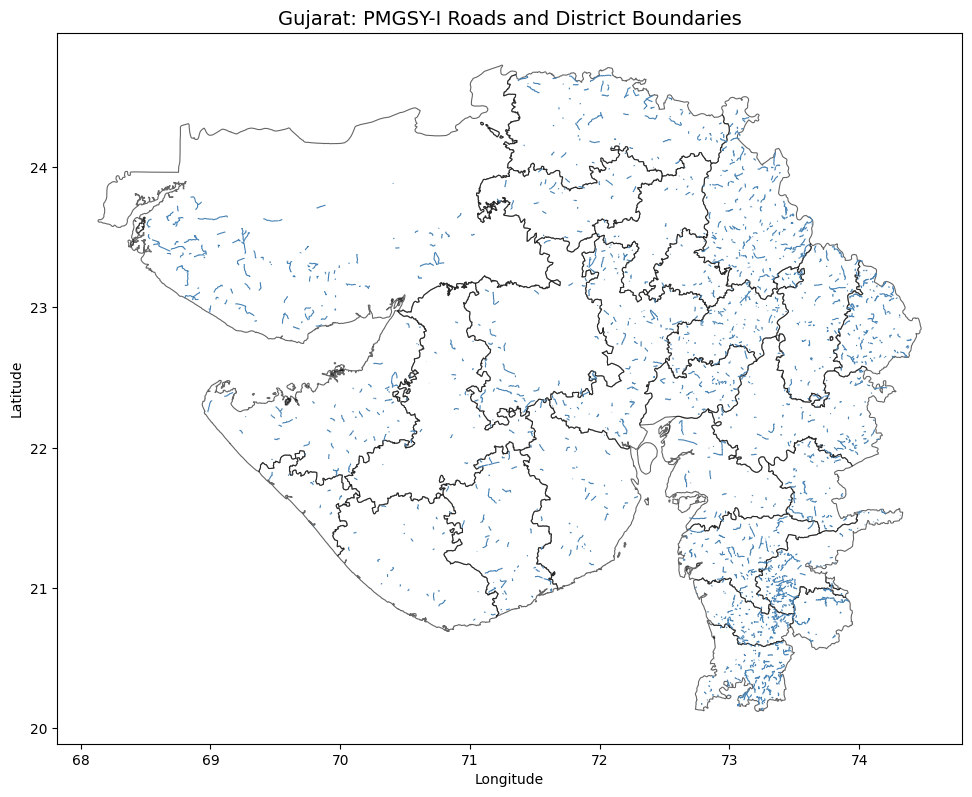

In [677]:
# Path to the Indian district shapefile
roads_path = r"PMGSY-6states-20260222T075336Z-1-001\PMGSY-6states\PMGSY-I\Proposal_PMGSY-I_Gujarat"

# Check path
print("Using shapefile path:", roads_path)

# Load the shapefile
gujarat_pmgsy1 = gpd.read_file(roads_path)

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 8))

# Plot districts (green background)
gujarat_d.plot(ax=ax1, color='none', edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
gujarat_pmgsy1.plot(ax=ax1, color='steelblue', linewidth=0.8)

# Add title and clean layout
ax1.set_title("Gujarat: PMGSY-I Roads and District Boundaries", fontsize=14)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Spatial Join--- checking pmgsy1 roads and villages in vills_pmgsy
predicate='intersects': This will join a linestring to a polygon if any part of the linestring's boundary or interior touches the polygon's boundary or interior. This is generally the most useful predicate for lines and polygons.

In [678]:
#make sure crs matches
vills_pmgsy = vills_pmgsy.to_crs(gujarat_pmgsy1.crs)

#spatial join
villages_with_roads = gpd.sjoin(
    vills_pmgsy, #merged shapefile of villages with pmgsy info to those villages
    gujarat_pmgsy1, #shapefile of pmgsy1 proposed roads
    predicate="intersects",
    how="inner"
)

roads_with_villages = gpd.sjoin(
    gujarat_pmgsy1, #shapefile of pmgsy1 proposed roads
    vills_pmgsy, #merged shapefile of villages with pmgsy info to those villages
    predicate="intersects",
    how="inner"
)

In [679]:
print("num villages with pmgsy roads before Spatial Join:", vills_pmgsy.shape)
print("After Spatial Join:", villages_with_roads.shape)

num villages with pmgsy roads before Spatial Join: (2113, 26)
After Spatial Join: (1156, 39)


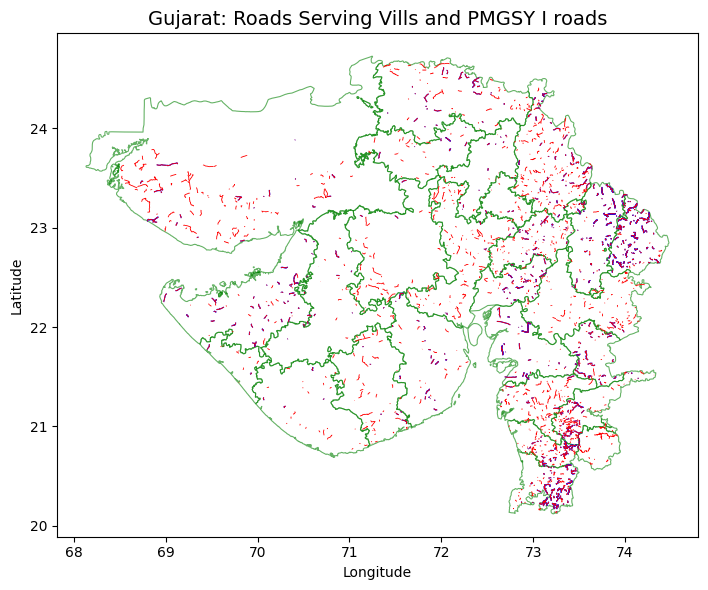

In [680]:
#graph it
fig, ax = plt.subplots(figsize=(8,6))

# Plot districts (green background)
gujarat_d.plot(ax=ax, color='none', edgecolor='green', linewidth=0.8, alpha=0.6)

# Plot roads (blue lines)
roads_with_villages.plot(ax=ax, color='blue', linewidth=0.8)

# Plot roads (blue lines)
gujarat_pmgsy1.plot(ax=ax, color='red', linewidth=0.6)

# Add title and clean layout
ax.set_title("Gujarat: Roads Serving Vills and PMGSY I roads", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Ensure same CRS
gujarat_pmgsy1 = gujarat_pmgsy1.to_crs(gujarat_d.crs)

In [681]:
# figure out diff between roads that served vills and all pmgsy1 roads
print("roads serving:", roads_with_villages.shape)
print("all pmgsy1:", gujarat_pmgsy1.shape)

roads serving: (1156, 39)
all pmgsy1: (2435, 13)


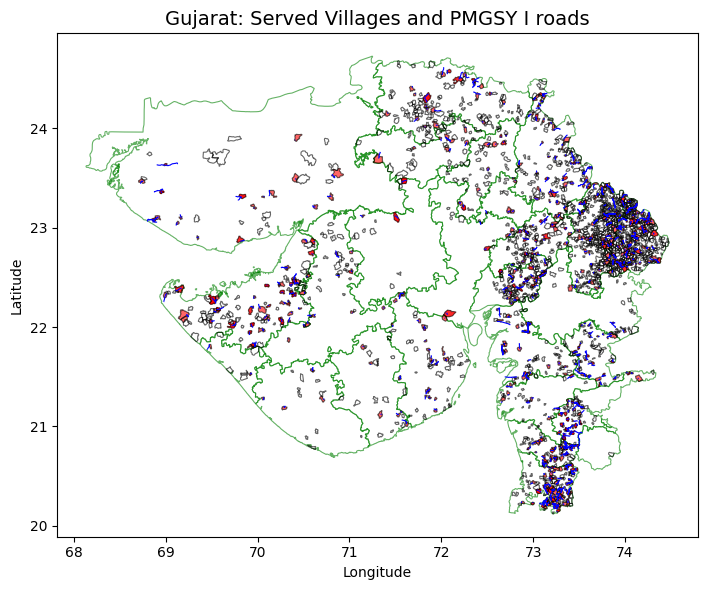

In [682]:
#graph it
fig, ax3 = plt.subplots(figsize=(8,6))

# Plot districts (green background)
gujarat_d.plot(ax=ax3, color='none', edgecolor='green', linewidth=0.8, alpha=0.6)

#plot unique villages spatial joined with pmgsy1 roads 
villages_with_roads.plot(ax=ax3, color='red', linewidth=0.8, alpha=0.6) 

#vills_info (before spatial join)
vills_pmgsy.plot(ax=ax3, color='none',edgecolor='black', linewidth=0.8, alpha=0.6) 

# Plot roads (blue lines)
roads_with_villages.plot(ax=ax3, color='blue', linewidth=0.8)

# Add title and clean layout
ax3.set_title("Gujarat: Served Villages and PMGSY I roads", fontsize=14)
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

### Three graphs

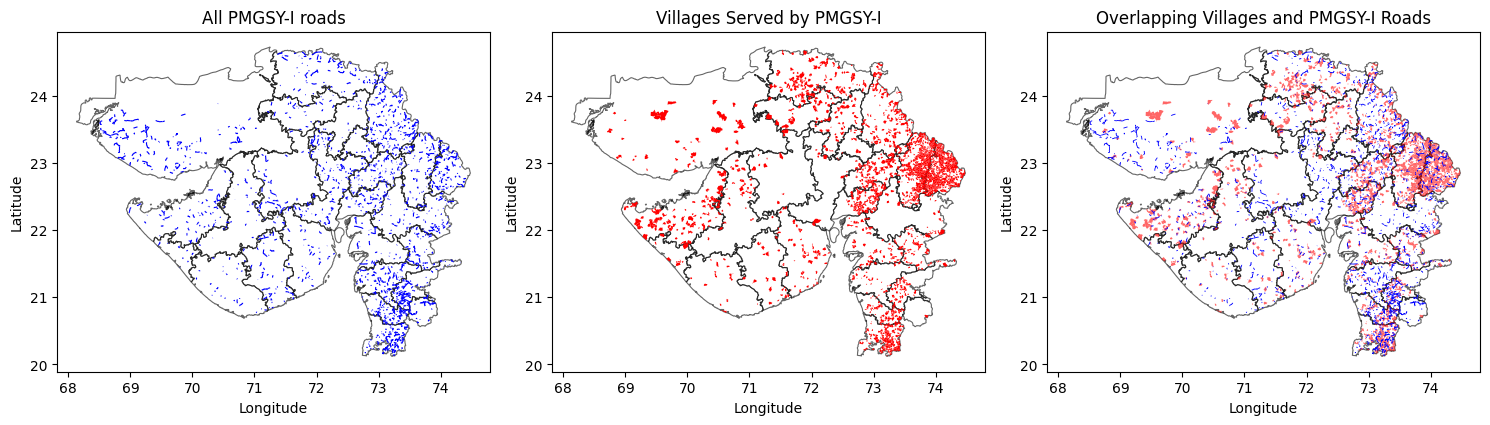

In [683]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 4)) #

# Plot data on each axis
gujarat_d.plot(ax=ax1, color='none', edgecolor='black', linewidth=0.8, alpha=0.6)
gujarat_pmgsy1.plot(ax=ax1, color='blue', linewidth=0.8)
ax1.set_title('All PMGSY-I roads') #
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

gujarat_d.plot(ax=ax2, color='none', edgecolor='black', linewidth=0.8, alpha=0.6)
vills_pmgsy.plot(ax=ax2, color='red', linewidth=0.2)
ax2.set_title('Villages Served by PMGSY-I')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

gujarat_d.plot(ax=ax3, color='none', edgecolor='black', linewidth=0.8, alpha=0.6)
#roads_with_villages #villages_with_roads
vills_pmgsy.plot(ax=ax3, color='red', linewidth=0.8, alpha=0.6) 
gujarat_pmgsy1.plot(ax=ax3, color='blue', linewidth=0.6)
ax3.set_title('Overlapping Villages and PMGSY-I Roads')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()

# Display the figure
plt.show()

In [684]:
villages_with_roads.columns

Index(['shrid2', 'pc11_id', 'n', 'polysource', 'n_ncontig', 'maxdist_km',
       'geometry', 'state', 'road_award_date_new', 'road_award_date_upg',
       'road_comp_date_new', 'road_comp_date_upg', 'road_comp_date_stip_new',
       'road_comp_date_stip_upg', 'road_sanc_year_new', 'road_sanc_year_upg',
       'road_length_new', 'road_length_upg', 'road_cost_new', 'road_cost_upg',
       'road_cost_sanc_new', 'road_cost_sanc_upg', 'road_cost_state_new',
       'road_cost_state_upg', 'road_name_new', 'road_name_upg', 'index_right',
       'MRL_ID', 'STATE_ID', 'DISTRICT_I', 'LGD_STATE', 'LGD_DISTRI',
       'BLOCK_ID', 'CN_CODE', 'PROPOSED_L', 'WORK_NAME', 'IMS_YEAR',
       'IMS_BATCH', 'Proposal_T'],
      dtype='str')

In [685]:
villages_with_roads[['road_award_date_new', 'road_award_date_upg',
       'road_comp_date_new', 'road_comp_date_upg', 'road_comp_date_stip_new',
       'road_comp_date_stip_upg', 'road_sanc_year_new', 'road_sanc_year_upg',
       'road_length_new', 'road_length_upg', 'road_cost_new', 'road_cost_upg',
       'road_cost_sanc_new', 'road_cost_sanc_upg', 'road_cost_state_new',
       'road_cost_state_upg', 'road_name_new', 'road_name_upg']]

,road_award_date_new,road_award_date_upg,road_comp_date_new,road_comp_date_upg,road_comp_date_stip_new,road_comp_date_stip_upg,road_sanc_year_new,road_sanc_year_upg,road_length_new,road_length_upg,road_cost_new,road_cost_upg,road_cost_sanc_new,road_cost_sanc_upg,road_cost_state_new,road_cost_state_upg,road_name_new,road_name_upg
1,2005-08-01,NaN,2006-03-01,NaN,2006-05-30,NaN,2004.0,NaN,1.1,NaN,12.07,NaN,10.4,NaN,0.0,NaN,O.D.R. to Audivandh Road,NaN
1,2005-08-01,NaN,2006-03-01,NaN,2006-05-30,NaN,2004.0,NaN,1.1,NaN,12.07,NaN,10.4,NaN,0.0,NaN,O.D.R. to Audivandh Road,NaN
6,2002-05-13,NaN,2002-11-01,NaN,2002-07-12,NaN,2001.0,NaN,2.5,NaN,30.58,NaN,30.56,NaN,0.0,NaN,Othavadi Vistar (Bhimasar) app. road,NaN
8,2005-04-29,NaN,2006-07-01,NaN,2006-01-28,NaN,2004.0,NaN,8.0,NaN,120.28,NaN,117.37,NaN,0.0,NaN,Sanava to Fulpura Road,NaN
9,2002-05-13,NaN,2002-11-01,NaN,2002-07-12,NaN,2001.0,NaN,0.7,NaN,10.49,NaN,11.64,NaN,0.0,NaN,Lala Hirani Vandh app. road,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2110,2002-03-06,NaN,2002-10-01,NaN,2002-09-05,NaN,2001.0,NaN,1.3,NaN,13.09,NaN,13.99,NaN,0.0,NaN,Dhodiawad Falia Road,NaN
2110,2002-03-06,NaN,2002-10-01,NaN,2002-09-05,NaN,2001.0,NaN,1.3,NaN,13.09,NaN,13.99,NaN,0.0,NaN,Dhodiawad Falia Road,NaN
2110,2002-03-06,NaN,2002-10-01,NaN,2002-09-05,NaN,2001.0,NaN,1.3,NaN,13.09,NaN,13.99,NaN,0.0,NaN,Dhodiawad Falia Road,NaN
2110,2002-03-06,NaN,2002-10-01,NaN,2002-09-05,NaN,2001.0,NaN,1.3,NaN,13.09,NaN,13.99,NaN,0.0,NaN,Dhodiawad Falia Road,NaN


#### centroid vs boundary

In [686]:
roads_with_villages['geometry']
villages_with_roads['geometry']

1       POLYGON ((69.01459 23.64677, 69.01406 23.64577...
1       POLYGON ((69.01459 23.64677, 69.01406 23.64577...
6       POLYGON ((70.88905 23.598, 70.89041 23.59779, ...
8       POLYGON ((70.82003 23.33145, 70.81856 23.32958...
9       POLYGON ((70.41575 23.87192, 70.41259 23.87246...
                              ...                        
2110    POLYGON ((73.34709 20.89898, 73.34719 20.89828...
2110    POLYGON ((73.34709 20.89898, 73.34719 20.89828...
2110    POLYGON ((73.34709 20.89898, 73.34719 20.89828...
2110    POLYGON ((73.34709 20.89898, 73.34719 20.89828...
2112    POLYGON ((73.0531 24.06907, 73.05176 24.0697, ...
Name: geometry, Length: 1156, dtype: geometry

#### Checking upgrades 

In [687]:
roads_with_villages.columns

Index(['MRL_ID', 'STATE_ID', 'DISTRICT_I', 'LGD_STATE', 'LGD_DISTRI',
       'BLOCK_ID', 'CN_CODE', 'PROPOSED_L', 'WORK_NAME', 'IMS_YEAR',
       'IMS_BATCH', 'Proposal_T', 'geometry', 'index_right', 'shrid2',
       'pc11_id', 'n', 'polysource', 'n_ncontig', 'maxdist_km', 'state',
       'road_award_date_new', 'road_award_date_upg', 'road_comp_date_new',
       'road_comp_date_upg', 'road_comp_date_stip_new',
       'road_comp_date_stip_upg', 'road_sanc_year_new', 'road_sanc_year_upg',
       'road_length_new', 'road_length_upg', 'road_cost_new', 'road_cost_upg',
       'road_cost_sanc_new', 'road_cost_sanc_upg', 'road_cost_state_new',
       'road_cost_state_upg', 'road_name_new', 'road_name_upg'],
      dtype='str')

In [688]:
check_upgrades=roads_with_villages[['road_award_date_new','road_award_date_upg']].dropna(subset=['road_award_date_new','road_award_date_upg'])
# Drop rows that dont have both new date and upg date (only 13)

check_upgrades['upg_after_new']= check_upgrades['road_award_date_new']<=check_upgrades['road_award_date_upg']
print(check_upgrades['upg_after_new'].value_counts())
check_upgrades

upg_after_new
True     10
False     3
Name: count, dtype: int64


,road_award_date_new,road_award_date_upg,upg_after_new
225,2001-12-18,2002-06-10,True
262,2005-04-07,2002-01-18,False
443,2002-08-26,2002-08-26,True
445,2002-08-26,2002-08-26,True
724,2002-06-10,2009-02-05,True
731,2002-03-19,2003-01-22,True
965,2005-09-06,2006-09-25,True
983,2002-06-10,2009-02-05,True
1262,2002-01-16,2008-06-24,True
1911,2002-09-06,2001-10-19,False


## pmgsy-II

In [689]:
pmgsy2_path= r"PMGSY-6states-20260222T075336Z-1-001\PMGSY-6states\PMGSY-II\Proposal_PMGSY-II_Gujarat"
pmgsy2= gpd.read_file(pmgsy2_path)
pmgsy2.head()

,MRL_ID,STATE_ID,DISTRICT_I,LGD_STATE,LGD_DISTRI,BLOCK_ID,CN_CODE,PROPOSED_L,WORK_NAME,IMS_YEAR,IMS_BATCH,Proposal_T,geometry
0,171254,12,533,24,459,581,373260.0,14.22,T09-Ten Astan to Plasod Khoj Road (VR0126),2013,1,P,"LINESTRING (73.10665 21.1356, 73.10726 21.1358..."
1,171188,12,71,24,443,3547,65092.0,18.73,T25-Boradi Sedarda road (VR6/75),2013,1,P,"LINESTRING (71.7285 21.11164, 71.72889 21.1120..."
2,171241,12,421,24,455,4908,57810.0,11.40,T01-Bhilot Mahemdavad Road (04/42),2013,1,P,"LINESTRING (71.54665 23.8691, 71.54696 23.8692..."
3,171235,12,683,24,669,7702,319352.0,21.20,T21-Sanjeli Gothib Batakwada App Road (10/1),2013,1,P,"LINESTRING (73.97067 23.25911, 73.97016 23.259..."
4,171235,12,683,24,669,7702,319352.0,21.20,T21-Sanjeli Gothib Batakwada App Road (10/1),2013,1,P,"LINESTRING (73.98209 23.25555, 73.98173 23.254..."


In [690]:
pmgsy2['IMS_YEAR'].value_counts()

IMS_YEAR
2013    175
2018     38
Name: count, dtype: int64

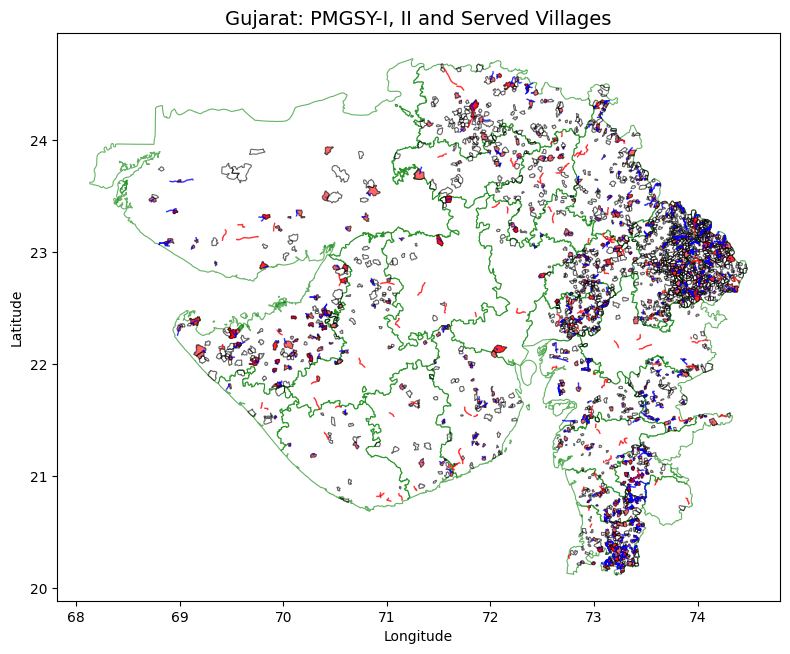

In [691]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot pmgsy1 roads serving villages
roads_with_villages.plot(ax=ax, color='blue', linewidth=1, alpha=0.8)

# Plot pmgsy2 roads
pmgsy2.plot(ax=ax, color='red', linewidth=1, alpha=0.8)

# Plot pmgsy2 districts
gujarat_d.plot(ax=ax, color='none', edgecolor='green', linewidth=0.8, alpha=0.6)

#plot unique villages spatial joined with pmgsy1 roads 
villages_with_roads.plot(ax=ax, color='red', linewidth=0.8, alpha=0.6) 

#vills_info (before spatial join)
vills_pmgsy.plot(ax=ax, color='none',edgecolor='black', linewidth=0.8, alpha=0.6) 

# Add title and clean layout
ax.set_title("Gujarat: PMGSY-I, II and Served Villages", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Ensure same CRS
vills_pmgsy = vills_pmgsy.to_crs(pmgsy2.crs)

## sjoin PMGSY-I and II with vills

In [692]:
gujarat_pmgsy12= pd.concat([gujarat_pmgsy1, pmgsy2], axis=0)

In [693]:
#make sure crs matches
vills_pmgsy = vills_pmgsy.to_crs(gujarat_pmgsy12.crs)

#spatial join
villages_with_12roads = gpd.sjoin(
    vills_pmgsy, #merged shapefile of villages with pmgsy info to those villages
    gujarat_pmgsy12, #shapefile of pmgsy1 proposed roads
    predicate="intersects",
    how="inner"
)

roads12_with_villages = gpd.sjoin(
    gujarat_pmgsy12, #shapefile of pmgsy1 proposed roads
    vills_pmgsy, #merged shapefile of villages with pmgsy info to those villages
    predicate="intersects",
    how="inner"
)

In [694]:
print("num of vills before sjoin:", vills_pmgsy.shape)
print("num of vills after sjoin:", villages_with_12roads.shape)
print("num of vills after sjoin just 1:", villages_with_roads.shape)
print("unaccounted for vills:",2113-1257)

num of vills before sjoin: (2113, 26)
num of vills after sjoin: (1257, 39)
num of vills after sjoin just 1: (1156, 39)
unaccounted for vills: 856


In [695]:
roads12_with_villages.head()

,MRL_ID,STATE_ID,DISTRICT_I,LGD_STATE,LGD_DISTRI,BLOCK_ID,CN_CODE,PROPOSED_L,WORK_NAME,IMS_YEAR,...,road_length_new,road_length_upg,road_cost_new,road_cost_upg,road_cost_sanc_new,road_cost_sanc_upg,road_cost_state_new,road_cost_state_upg,road_name_new,road_name_upg
0,51735,12,681,24,674,7688,175243.0,4.0,Krushangadh app. road,2000,...,NaN,4.0,NaN,27.01,NaN,26.64,NaN,0.0,NaN,Krushangadh app. road
3,181432,12,576,24,462,1574,NaN,0.0,Kosimpada Sondar - Murdad,2016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,52140,12,683,24,669,7703,298925.0,1.6,L072-Rampura App road,2013,...,1.15,NaN,19.92,NaN,22.12,NaN,0.0,NaN,Odhabhag Approach Road,NaN
6,53075,12,415,24,454,3931,224771.0,5.4,L063-MORVA NAGLOD ROAD,2013,...,1.38,NaN,17.37,NaN,15.04,NaN,0.0,NaN,M.D.R TO NAGLOD PRY.SCHOOL ROAD.,NaN
6,53075,12,415,24,454,3931,224771.0,5.4,L063-MORVA NAGLOD ROAD,2013,...,2.95,NaN,31.97,NaN,31.68,NaN,0.0,NaN,DANTIYA TO PATEL FALIA GANESH ROAD,NaN


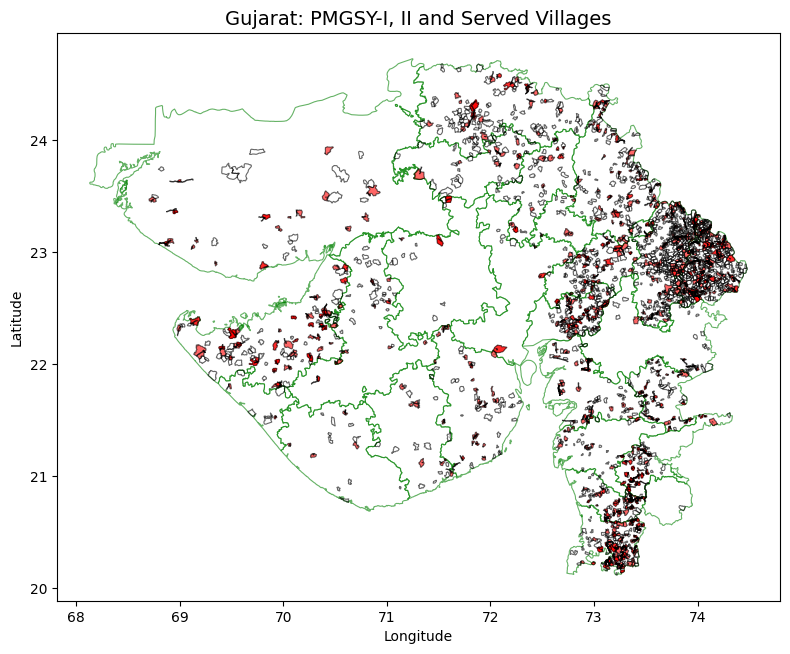

In [696]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot pmgsy1 roads serving villages
roads12_with_villages.plot(ax=ax, color='black', linewidth=1, alpha=0.8)

# Plot pmgsy2 districts
gujarat_d.plot(ax=ax, color='none', edgecolor='green', linewidth=0.8, alpha=0.6)

#plot unique villages spatial joined with pmgsy1 roads 
villages_with_12roads.plot(ax=ax, color='red', linewidth=0.8, alpha=0.6) 

#vills_info (before spatial join)
vills_pmgsy.plot(ax=ax, color='none',edgecolor='black', linewidth=0.8, alpha=0.6) 

# Add title and clean layout
ax.set_title("Gujarat: PMGSY-I, II and Served Villages", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


# Dataset 1—- all roads, and then for each road, shrid values in order! That it overlaps with 


In [697]:
print(roads_with_villages['shrid2'].duplicated().sum()) #405
villages_with_roads['shrid2'].duplicated().sum()
# the villages in the pmgsy2015 dataset are not overlapping with many pmgsy1 roads 
# because that is the whole point that that was their first pmgsy road
# So instead: find the number of total villages that are connected to each pmgsy1 road.

405


np.int64(405)

In [698]:
#gujarat_pmgsy1=gujarat_pmgsy1.rename(columns={"geometry":"geometry_road"})

In [699]:
# spatialjoin shrid2open_g with gujarat_pmgsy1 to find all villages that intersect with any pmgsy1 road, then find the number of unique villages that intersect with each road.
#shrid2open_g = shrid2open_g.to_crs(gujarat_pmgsy1.crs)

#spatial join--- village geometry 
all_vills_pmgsy1 = gpd.sjoin(
    shrid2open_g,  # shapefile of all villages 
    gujarat_pmgsy1, #shapefile of pmgsy1 proposed roads
    predicate="intersects",
    how="inner"
)
#spatial join--- roads geometry (this will give us all roads no matter what)
pmgsy1roads_all_vills = gpd.sjoin(
    gujarat_pmgsy1, #shapefile of pmgsy1 proposed roads
    shrid2open_g, # shapefile of all villages 
    predicate="intersects",
    how="left"
)

In [700]:
print(pmgsy1roads_all_vills['shrid2'].duplicated().sum()) #1480
all_vills_pmgsy1['shrid2'].duplicated().sum()

1480


np.int64(1454)

In [701]:
pmgsy1roads_all_vills['num_vills']=pmgsy1roads_all_vills.groupby("geometry")['shrid2'].transform('nunique')
pmgsy1roads_all_vills['num_vills'].value_counts()

num_vills
2     1448
3     1092
1     1035
4      600
5      330
6      186
8      112
7      105
10      40
0       27
9       27
14      14
13      13
Name: count, dtype: int64

In [702]:
Data1= pmgsy1roads_all_vills.groupby("geometry")['shrid2'].agg(list).reset_index().rename(columns={'shrid2': 'connected_vills'}).merge(
                    gujarat_pmgsy1[['geometry','PROPOSED_L', 'WORK_NAME', 'IMS_YEAR', 'IMS_BATCH']]
                    , on="geometry", how="left")
Data1['num_vills']=Data1['connected_vills'].apply(len)
Data1[['geometry','num_vills']].head()

,geometry,num_vills
0,"LINESTRING (70.75819 20.87019, 70.75847 20.870...",4
1,"LINESTRING (70.72583 20.91142, 70.72583 20.91142)",1
2,"LINESTRING (70.76032 20.98065, 70.76025 20.980...",1
3,"LINESTRING (70.75925 20.97398, 70.75929 20.974...",1
4,"LINESTRING (71.06182 20.97273, 71.06166 20.973...",1


In [703]:
Data1.head()

,geometry,connected_vills,PROPOSED_L,WORK_NAME,IMS_YEAR,IMS_BATCH,num_vills
0,"LINESTRING (70.75819 20.87019, 70.75847 20.870...","[11-24-479-03837-515117, 11-24-479-03837-51511...",8.2,Chhachhar - Jagatiya Shedhaya Arithiya Road,2006,1,4
1,"LINESTRING (70.72583 20.91142, 70.72583 20.91142)",[11-24-479-03837-515107],7.1,S.H. to Sandhnidhar - Valadar,2006,1,1
2,"LINESTRING (70.76032 20.98065, 70.76025 20.980...",[nan],1.3,Kansaria App. Road,2001,1,1
3,"LINESTRING (70.75925 20.97398, 70.75929 20.974...",[nan],1.3,Kansaria App. Road,2001,1,1
4,"LINESTRING (71.06182 20.97273, 71.06166 20.973...",[11-24-479-03838-515247],1.0,Nagadia Appr. - Road,2005,1,1


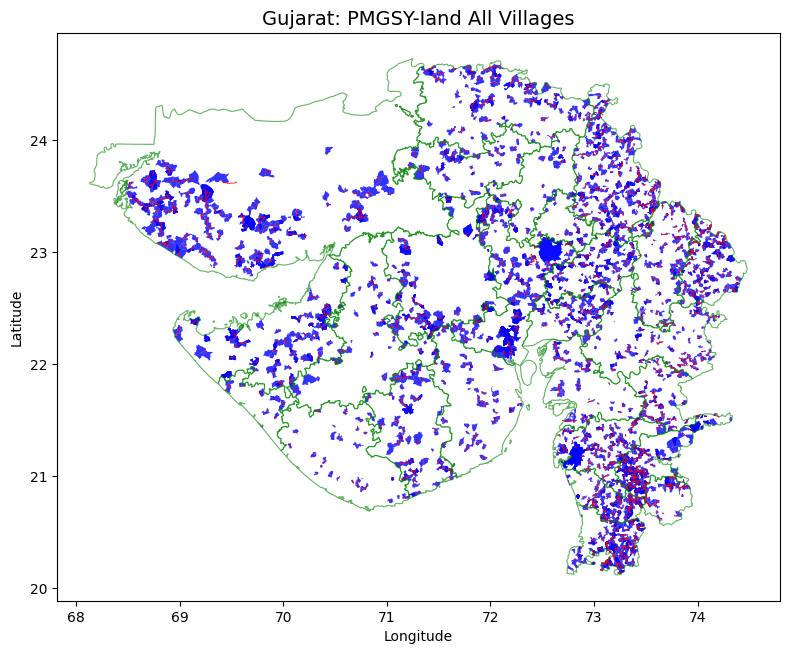

In [704]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot all villages connected by pmgsy1 roads
all_vills_pmgsy1.plot(ax=ax, color='blue', linewidth=1, alpha=0.8)

# Plot districts
gujarat_d.plot(ax=ax, color='none', edgecolor='green', linewidth=0.8, alpha=0.6)

#plot pmgsy1 roads and the villages they connect to 
#villages_with_roads.plot(ax=ax, color='red', linewidth=0.8, alpha=0.6) 

#vills_info (before spatial join)
#vills_pmgsy.plot(ax=ax, color='none',edgecolor='black', linewidth=0.8, alpha=0.6) 

#Pmgsy 1 roads 
gujarat_pmgsy1.plot(ax=ax, color='red', linewidth=0.6)

# Add title and clean layout
ax.set_title("Gujarat: PMGSY-Iand All Villages", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Dataset 2— for each village, how many villages can it be connected to through one road
Check the literature, number of links, how many villages/links would you need to go through to connect to a village.


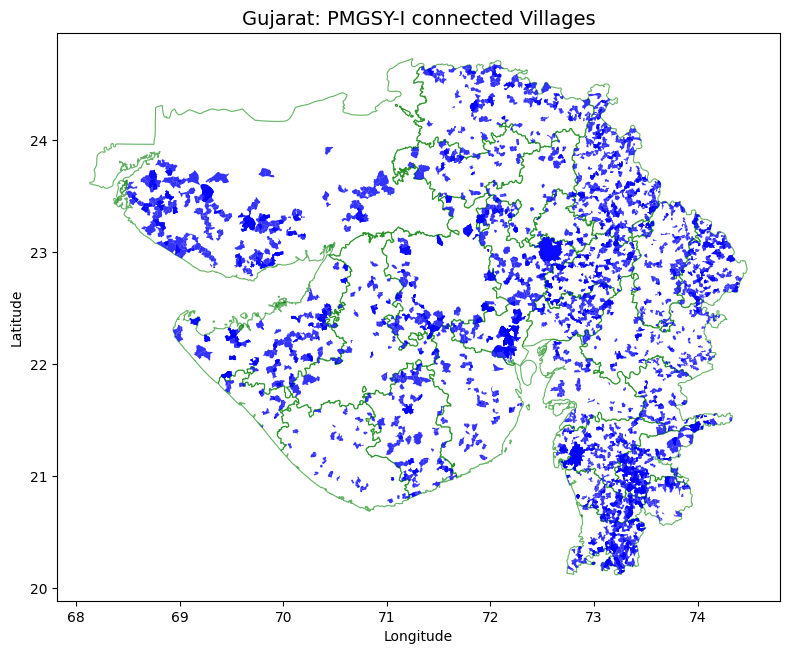

In [705]:
fig, ax = plt.subplots(figsize=(8, 8))
# Plot districts
gujarat_d.plot(ax=ax, color='none', edgecolor='green', linewidth=0.8, alpha=0.6)

all_vills_pmgsy1.plot(ax=ax, color='blue', linewidth=1, alpha=0.8)
# Add title and clean layout
ax.set_title("Gujarat: PMGSY-I connected Villages", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


In [706]:
p2015shrids= vills_pmgsy_info_clean['shrid2'].tolist()

In [707]:
#first identify which of these villages are included in the pmgsy_2015 dataset
all_vills_pmgsy1['Received_road_2015']= all_vills_pmgsy1['shrid2'].apply(lambda x: x in p2015shrids)
all_vills_pmgsy1.head(1)

,shrid2,pc11_id,n,geometry_t,polysource,n_ncontig,maxdist_km,geometry,state,index_right,...,LGD_STATE,LGD_DISTRI,BLOCK_ID,CN_CODE,PROPOSED_L,WORK_NAME,IMS_YEAR,IMS_BATCH,Proposal_T,Received_road_2015
458375,11-24-468-03722-506432,506432,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,"POLYGON ((68.88013 23.80215, 68.88004 23.80157...",24,14,...,24,449,3348,342803.0,14.55,S.H. - Siyot Guneri Road,2007,1,P,False


In [708]:
#Get villages per road
road_to_villages = (
    all_vills_pmgsy1
    .groupby('index_right')['shrid2']
    .agg(list)
    .reset_index()
)

# Step 3: explode back to village level with co-villages
village_connections = all_vills_pmgsy1.merge(
    road_to_villages,
    on='index_right',
    suffixes=('', '_connected')
)

# Step 4: remove self from list
village_connections['connected_villages'] = village_connections.apply(
    lambda row: [v for v in row['shrid2_connected'] if v != row['shrid2']],
    axis=1
)

# Step 5: aggregate per village
final = (
    village_connections
    .groupby('shrid2')['connected_villages']
    .agg(lambda lists: list(set([v for sublist in lists for v in sublist])))
    .reset_index()
)

# Step 6: count connections
final['num_connected_villages'] = final['connected_villages'].apply(len)

final.head()

,shrid2,connected_villages,num_connected_villages
0,11-24-468-03722-506432,"[11-24-468-03722-506453, 11-24-468-03722-50643...",4
1,11-24-468-03722-506433,"[11-24-468-03722-506453, 11-24-468-03722-50643...",4
2,11-24-468-03722-506434,"[11-24-468-03722-506453, 11-24-468-03722-506435]",2
3,11-24-468-03722-506435,"[11-24-468-03722-506433, 11-24-468-03722-50643...",5
4,11-24-468-03722-506436,"[11-24-468-03722-506453, 11-24-468-03722-50643...",4


In [750]:
focus_D2= all_vills_pmgsy1[all_vills_pmgsy1['Received_road_2015'] == True].groupby('shrid2').size().reset_index().rename(columns={0:'num_connected_roads'})

# make a key to index roads 
roadskey_g= pmgsy1roads_all_vills[pmgsy1roads_all_vills['geometry'].isin(
    pmgsy1roads_all_vills['geometry'].unique())].reset_index(names="road_index")
roads_with_key= pmgsy1roads_all_vills.merge(roadskey_g[['geometry', 'road_index']], on='geometry', how='left')

#Use lambda x: list(set(x)) to quickly get unique values. Note that set does not preserve the original order.
roads_D2=roads_with_key.groupby('shrid2')[['road_index']].agg(lambda x: list(dict.fromkeys(x))).reset_index().rename(columns={'geometry':'road_geometry'})

# Merge only the pmgsy1 roads that served villages with the dataset of all villages and their connected roads. 
Data2=focus_D2.merge(roads_D2, on='shrid2', how='left') 
roads_D2.head(1)
roadskey_g.head(1)


,road_index,MRL_ID,STATE_ID,DISTRICT_I,LGD_STATE,LGD_DISTRI,BLOCK_ID,CN_CODE,PROPOSED_L,WORK_NAME,...,index_right,shrid2,pc11_id,n,geometry_t,polysource,n_ncontig,maxdist_km,state,num_vills
0,0,51735,12,681,24,674,7688,175243.0,4.0,Krushangadh app. road,...,465822.0,11-24-477-03820-514025,514025,1.0,Polygon,1 shrid = 1 pc polygon,NaN,NaN,24,1


In [751]:
Dataset2= final.merge(Data2[['shrid2', 'num_connected_roads','road_index']], on='shrid2', how='inner')
Dataset2.head()

,shrid2,connected_villages,num_connected_villages,num_connected_roads,road_index
0,11-24-468-03722-506476,"[11-24-468-03722-506475, 11-24-468-03722-50647...",6,2,"[1990, 1991]"
1,11-24-468-03723-506570,"[11-24-468-03723-506589, 11-24-468-03723-506571]",2,1,[2416]
2,11-24-468-03723-506622,"[11-24-468-03723-506621, 11-24-468-03723-506620]",2,1,[1995]
3,11-24-468-03724-506629,[],0,1,[337]
4,11-24-468-03724-506638,[],0,1,[1073]


In [752]:
Dataset2.to_csv("Gujarat_PMGSY_Dataset2.csv", index=False)

# Dataset 3— villages, how many other shirds is it connected, the size (population) and town/village status (SHRUG Data) of all of the shrids its connected to

In [711]:
# read in town/village status ShRUG
# Path to the Indian district shapefile
pop_path = r"shrug-pc-keys-csv\pc11r_shrid_key.csv"

# Check path
print("Using shapefile path:", pop_path)

# Load the shapefile
pop_shrid = gpd.read_file(pop_path)

Using shapefile path: shrug-pc-keys-csv\pc11r_shrid_key.csv


In [712]:
#only gujarat 
pop_shrid_g=pop_shrid[pop_shrid['pc11_state_id'] == '24']
pop_shrid_g.shape

(17843, 7)

In [713]:
#making sure--- are there any of our 2015 shrids that have pop data?
pop_shrid_g['shrid2'].apply(lambda x: x in p2015shrids).sum() #2114 out of 17843

np.int64(2114)

In [714]:
final.head()

,shrid2,connected_villages,num_connected_villages
0,11-24-468-03722-506432,"[11-24-468-03722-506453, 11-24-468-03722-50643...",4
1,11-24-468-03722-506433,"[11-24-468-03722-506453, 11-24-468-03722-50643...",4
2,11-24-468-03722-506434,"[11-24-468-03722-506453, 11-24-468-03722-506435]",2
3,11-24-468-03722-506435,"[11-24-468-03722-506433, 11-24-468-03722-50643...",5
4,11-24-468-03722-506436,"[11-24-468-03722-506453, 11-24-468-03722-50643...",4


In [754]:
# explode village connections
temp = Dataset2[['shrid2', 'connected_villages', 'num_connected_roads']].explode('connected_villages')

# merge population
merge = temp.merge(
    pop_shrid_g[['shrid2', 'pc11_pca_tot_p']],
    left_on='connected_villages',
    right_on='shrid2',
    how='left',
    suffixes=('', '_connected')
)

# add in town/village status
merge['Town']= pd.to_numeric(
    merge['pc11_pca_tot_p'],
    errors='coerce'   # converts bad values to NaN
)>2500
# aggregate back
agg = merge.groupby('shrid2').agg({
    'pc11_pca_tot_p': list,
    'Town': 'sum'
}).reset_index().rename(columns={'pc11_pca_tot_p': 'connected_populations'}).rename({'Town': 'Town-Connected'}, axis=1)

# merge back to final
Dataset3 = final.merge(agg, on='shrid2', how='left')
Dataset3.notna().sum()
Dataset3[Dataset3['Town-Connected'].notna()].head(1)

,shrid2,connected_villages,num_connected_villages,connected_populations,Town-Connected
15,11-24-468-03722-506476,"[11-24-468-03722-506475, 11-24-468-03722-50647...",6,"[469.0, 4398.0, 793.0, 445.0, 2265.0, 783.0]",1.0


In [ ]:
temp['connected_villages']
temp_pop= temp.merge(pop_shrid_g[['shrid2','pc11_pca_tot_p']], left_on='connected_villages', right_on='shrid2', how="inner")
temp_pop[['pc11_pca_tot_p']].notna().sum()

pc11_pca_tot_p    1851
dtype: int64

In [732]:
print("percent of D3 with no pop data for connected villages", Dataset3['connected_populations'].isna().sum()/len(Dataset3)) 
agg.head()

percent of D3 with no pop data for connected villages 0.7883314543404735


,shrid2,connected_populations,Town-Connected
0,11-24-468-03722-506476,"[469.0, 4398.0, 793.0, 445.0, 2265.0, 783.0]",1
1,11-24-468-03723-506570,"[1835.0, 2571.0]",1
2,11-24-468-03723-506622,"[1668.0, 913.0]",0
3,11-24-468-03724-506629,[nan],0
4,11-24-468-03724-506638,[nan],0


In [727]:
merge.head()

,shrid2,connected_villages,shrid2_connected,pc11_pca_tot_p,Town
0,11-24-468-03722-506476,11-24-468-03722-506475,11-24-468-03722-506475,469.0,False
1,11-24-468-03722-506476,11-24-468-03722-506470,11-24-468-03722-506470,4398.0,True
2,11-24-468-03722-506476,11-24-468-03727-506926,11-24-468-03727-506926,793.0,False
3,11-24-468-03722-506476,11-24-468-03727-506925,11-24-468-03727-506925,445.0,False
4,11-24-468-03722-506476,11-24-468-03722-506474,11-24-468-03722-506474,2265.0,False


In [728]:
Dataset3.to_csv("Gujarat_PMGSY_Dataset3.csv", index=False)

# Dataset 4--- Distance weighted Market Access Score

In [756]:
Dataset3['Town-Connected'].value_counts()

Town-Connected
0.0    366
1.0    239
2.0     86
3.0     44
4.0     15
5.0      1
Name: count, dtype: int64

In [757]:
# make a dataset with just the villages that have a town connected to them
village_town= Dataset3[Dataset3['Town-Connected']>0]
village_town.head(1)

,shrid2,connected_villages,num_connected_villages,connected_populations,Town-Connected
15,11-24-468-03722-506476,"[11-24-468-03722-506475, 11-24-468-03722-50647...",6,"[469.0, 4398.0, 793.0, 445.0, 2265.0, 783.0]",1.0


In [ ]:
pmgsy1roads_all_vills['geometry']

toy= Dataset2[Dataset2['shrid2']=='11-24-468-03723-506570']
toy #11-24-468-03723-506570	[11-24-468-03723-506589, 11-24-468-03723-506571]	2	1	[2416]

,shrid2,connected_villages,num_connected_villages,num_connected_roads,road_index
1,11-24-468-03723-506570,"[11-24-468-03723-506589, 11-24-468-03723-506571]",2,1,[2416]


In [768]:
pmgsy1roads_all_vills[pmgsy1roads_all_vills['shrid2']=='11-24-468-03723-506570']['geometry']

2416    LINESTRING (70.81528 23.53997, 70.81357 23.533...
Name: geometry, dtype: geometry

#### Toy example

In [783]:
# finding the distance between the focus villages and their town connections on the pmgy road
from shapely.geometry import LineString, Polygon

line=pmgsy1roads_all_vills[pmgsy1roads_all_vills['shrid2']=='11-24-468-03723-506570']['geometry'].iloc[0]
poly1= shrid2open_g[shrid2open_g['shrid2']=='11-24-468-03723-506570']['geometry'].iloc[0]
poly2= shrid2open_g[shrid2open_g['shrid2']=='11-24-468-03723-506571']['geometry'].iloc[0] #11-24-468-03723-506571 is a town
# 1. Find the intersection of the line with each polygon
# Note: For overlapping polygons, this may result in a LineString. 
# We take the representative point (e.g., the exit point or centroid of intersection)
inter1 = line.intersection(poly1).centroid 
inter2 = line.intersection(poly2).centroid

# 2. Get the distance along the line to these points
# .project() returns the distance from the LineString's start to the point
dist_to_p1 = line.project(inter1)
dist_to_p2 = line.project(inter2)

# 3. Calculate distance between the two points along the line
distance_between = abs(dist_to_p2 - dist_to_p1)

print(f"Distance along the line: {distance_between}")


Distance along the line: 0.018795986891590677


In [784]:
#Use the .is_projected attribute to see if the CRS uses a 2D Cartesian plane (meters) instead of degrees.
line.crs

AttributeError: 'LineString' object has no attribute 'crs'

In [776]:
merge[merge['shrid2']=='11-24-468-03723-506570']

,shrid2,connected_villages,num_connected_roads,shrid2_connected,pc11_pca_tot_p,Town
6,11-24-468-03723-506570,11-24-468-03723-506589,1,11-24-468-03723-506589,1835.0,False
7,11-24-468-03723-506570,11-24-468-03723-506571,1,11-24-468-03723-506571,2571.0,True
